# Singlet Atlas Quickstart

Browse the **Singlet Atlas** — a single-cell genomics atlas built from public GEO/SRA data,
processed through the singlify pipeline. The `singlet-bio` Python package ships with a
bundled catalog that works **offline** with no downloads required.

```bash
pip install singlet-bio
```

In [1]:
import singlet

# One-line atlas summary
singlet.summary()

singlet atlas: 2,386 samples (993 SUCCESS) • 1,178 series • 7 species • 2.9M cells


In [2]:
# Browse species
singlet.species()

['Danio rerio', 'Drosophila melanogaster', 'Gallus gallus', 'Homo sapiens', 'Macaca mulatta', 'Mus musculus', 'Pan troglodytes']

In [3]:
# Top series by cell count
singlet.top_series(n=5)

,gse_id,n_samples,total_cells,avg_mapping_rate,organism,avg_median_genes
0,GSE174399,8,118126.0,0.957237,Homo sapiens,243.000000
1,GSE127918,12,116925.0,0.661725,Homo sapiens,175.250000
2,GSE173756,12,102346.0,0.904283,Homo sapiens,413.750000
3,GSE245310,14,91884.0,0.928445,Homo sapiens,107.307692
4,GSE200277,9,54759.0,0.838907,Homo sapiens,525.250000


In [4]:
# Text search across GEO titles
lung = singlet.samples(search='lung')
print(f'{len(lung)} samples matching "lung"')
lung[['gsm_id', 'organism', 'cells_called', 'mapping_rate', 'title']].head(5)

32 samples matching 'lung'


,gsm_id,organism,cells_called,mapping_rate,title
0,GSM2855482,Homo sapiens,0.0,0.94310,Lung_3_1
1,GSM2855483,Homo sapiens,0.0,0.93860,Lung_3_2
2,GSM6255587,Homo sapiens,10596.0,0.79320,D492 GEX lung
3,GSM5230177,Macaca mulatta,0.0,0.00000,Rh-Lung-25_POB [RhLung420-18]
4,GSM5136170,Mus musculus,12185.0,0.20603,Single cell RNA sequencing of the lung pre-metastatic niche in a syngeneic mouse model of rhabdomyosarcoma


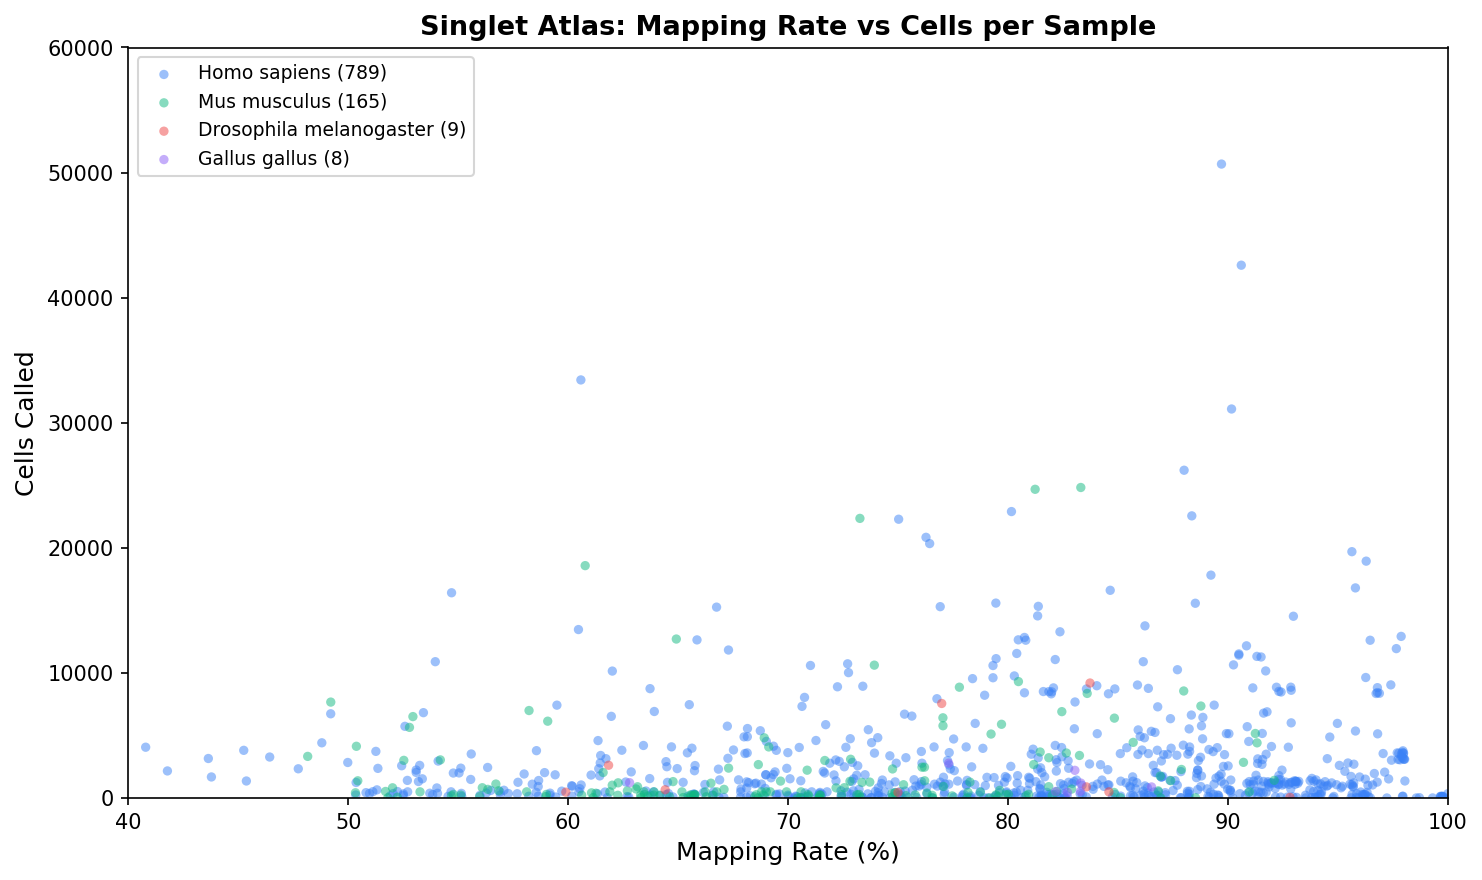

In [5]:
import matplotlib.pyplot as plt

# Atlas overview: mapping rate vs cells, colored by species
df = singlet.sample_index()
success = df[df['status'] == 'SUCCESS']

species_colors = {'Homo sapiens': '#3b82f6', 'Mus musculus': '#10b981',
                  'Macaca fascicularis': '#f59e0b', 'Drosophila melanogaster': '#ef4444'}

fig, ax = plt.subplots(figsize=(10, 6))
for sp, color in species_colors.items():
    sub = success[success['organism'] == sp]
    if len(sub) > 0:
        ax.scatter(sub['mapping_rate']*100, sub['cells_called'],
                   alpha=0.5, s=20, c=color, label=f'{sp} ({len(sub)})', edgecolors='none')
ax.set_xlabel('Mapping Rate (%)')
ax.set_ylabel('Cells Called')
ax.set_title('Singlet Atlas: Quality vs Yield by Species', fontweight='bold')
ax.legend(fontsize=9)
ax.set_ylim(0, 60000)
plt.tight_layout()
plt.show()

## Next Steps

- **Load a sample**: `singlet.load_dir('/path/to/quant/GSM...')` → AnnData with full QC
- **Read .1pz**: `singlet.io.read_1pz('gene_counts.1pz')` → sparse matrix
- **Browse online**: [singlet.bio](https://singlet.bio) for interactive exploration

See the [full notebook collection](https://github.com/Singlet-Bio/singlet/tree/main/notebooks) for validation, QC, and analysis examples.